In [1]:
import matplotlib.pyplot as plt
import numpy as np
import treecorr
from sp_validation.cosmo_val import CosmologyValidation
import scipy.stats as stats
from IPython.display import Markdown, display
import camb
%matplotlib inline

In [6]:
cv = CosmologyValidation(
    versions=["SP_v1.4.6.3_A", "SP_v1.4.6.3_A_leak_corr"],
    npatch=100,
    nrandom_cell=25,
    cell_method="catalog"
)

Plotting pseudo-Cl's

Computing pseudo-Cl's
SP_v1.4.6.3_A
Skipping Pseudo-Cl's calculation, /automnt/n17data/sguerrini/sp_validation/cosmo_val/output/pseudo_cl_SP_v1.4.6.3_A.fits exists
SP_v1.4.6.3_A_leak_corr
Skipping Pseudo-Cl's calculation, /automnt/n17data/sguerrini/sp_validation/cosmo_val/output/pseudo_cl_SP_v1.4.6.3_A_leak_corr.fits exists
Done pseudo-Cl's

Computing Pseudo-Cl covariance
SP_v1.4.6.3_A
Skipping Pseudo-Cl covariance calculation, /automnt/n17data/sguerrini/sp_validation/cosmo_val/output/pseudo_cl_cov_SP_v1.4.6.3_A.fits exists
SP_v1.4.6.3_A_leak_corr
Skipping Pseudo-Cl covariance calculation, /automnt/n17data/sguerrini/sp_validation/cosmo_val/output/pseudo_cl_cov_SP_v1.4.6.3_A_leak_corr.fits exists
Done Pseudo-Cl covariance


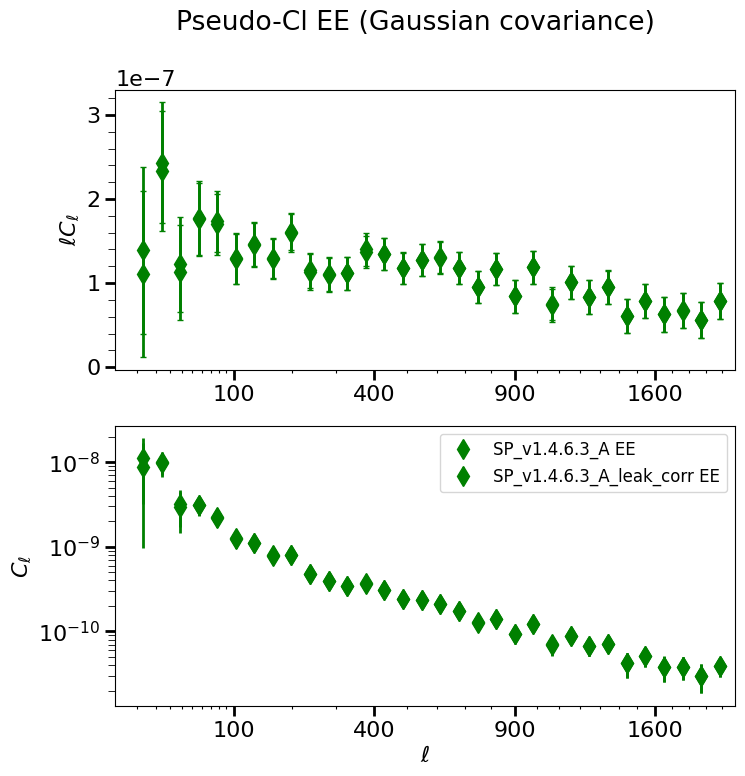

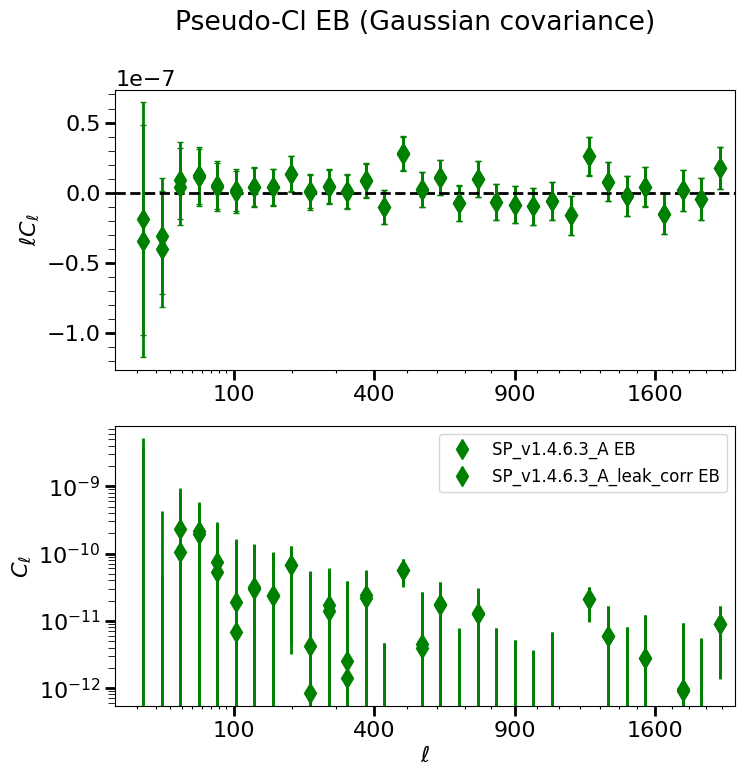

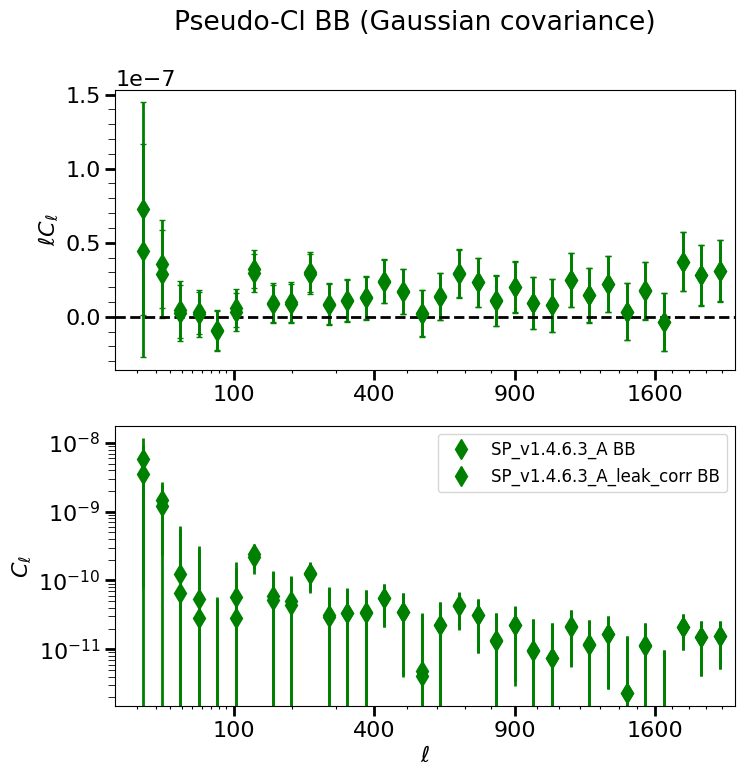

In [7]:
cv.plot_pseudo_cl() #Loads c_ells in cv object

In [8]:
def get_chi2_and_pte(data_vector, cov, verbose=True):
    """
    Calculate chi2 and pte for a given data vector and covariance matrix.
    """
    # Calculate chi2
    chi2 = data_vector @ np.linalg.inv(cov) @ data_vector
    if verbose:
        print(f"Chi2: {chi2:.4f}")
    
    #Calculate the reduced chi^2
    dof = len(data_vector)
    reduced_chi2 = chi2 / dof
    if verbose:
        print(f"Reduced Chi2: {reduced_chi2:.4f}")
    
    # Calculate pte
    pte = 1 - stats.chi2.cdf(chi2, dof)
    if verbose:
        print(f"PTE: {pte:.4f}")
    
    return chi2, reduced_chi2, pte

In [9]:
header = (
        "| Root | $\chi^2$ (EB) | $\chi^2$ (EB) / dof | p-val (EB)| $\chi^2$ (BB) | $\chi^2$ (BB) / dof | p-val (BB) |\n"
        "|------|----------------|------------|---------------|------------|------------------|--------------|\n"
    )

rows = []

for key in cv._pseudo_cls.keys():
    print(f"Key: {key}")
    row = f"| `{key}` "
    print("Metrics for EB pseudo cells:")
    data_vector = cv._pseudo_cls[key]["pseudo_cl"]["EB"]
    cov = cv._pseudo_cls[key]["cov"]["COVAR_EB_EB"].data
    chi2, reduced_chi2, pte = get_chi2_and_pte(data_vector, cov)
    row += f"| {chi2:.4f} | {reduced_chi2:.4f} | {pte:.4f} "

    print("Metrics for BB pseudo cells:")
    data_vector = cv._pseudo_cls[key]["pseudo_cl"]["BB"]
    cov = cv._pseudo_cls[key]["cov"]["COVAR_BB_BB"].data
    chi2, reduced_chi2, pte = get_chi2_and_pte(data_vector, cov)
    row += f"| {chi2:.4f} | {reduced_chi2:.4f} | {pte:.4f} |"
    rows.append(row)

# Display in Jupyter
display(Markdown(header + "\n".join(rows)))

Key: SP_v1.4.6.3_A
Metrics for EB pseudo cells:
Chi2: 20.7375
Reduced Chi2: 0.6480
PTE: 0.9373
Metrics for BB pseudo cells:
Chi2: 43.9877
Reduced Chi2: 1.3746
PTE: 0.0771
Key: SP_v1.4.6.3_A_leak_corr
Metrics for EB pseudo cells:
Chi2: 19.7316
Reduced Chi2: 0.6166
PTE: 0.9558
Metrics for BB pseudo cells:
Chi2: 40.8328
Reduced Chi2: 1.2760
PTE: 0.1361


| Root | $\chi^2$ (EB) | $\chi^2$ (EB) / dof | p-val (EB)| $\chi^2$ (BB) | $\chi^2$ (BB) / dof | p-val (BB) |
|------|----------------|------------|---------------|------------|------------------|--------------|
| `SP_v1.4.6.3_A` | 20.7375 | 0.6480 | 0.9373 | 43.9877 | 1.3746 | 0.0771 |
| `SP_v1.4.6.3_A_leak_corr` | 19.7316 | 0.6166 | 0.9558 | 40.8328 | 1.2760 | 0.1361 |

In [2]:
redshift_distr = np.loadtxt('/n17data/mkilbing/astro/data/CFIS/v1.0/nz/dndz_SP_A.txt')
z, dndz = redshift_distr[:, 0], redshift_distr[:, 1]

In [3]:
#Compute theory Cl'set
h = 0.7
Oc = 0.25
Ob = 0.05

pars = camb.set_params(H0=100*h, omch2=Oc*h**2, ombh2=Ob*h**2,
                                    NonLinear=camb.model.NonLinear_both, WantTransfer=True)

nside = 1024
lmax = 2*nside

#getthe expected cl's from CAMB
pars.min_l = 1
pars.set_for_lmax(lmax)
pars.SourceWindows = [
    camb.sources.SplinedSourceWindow(z=z, W=dndz, source_type='lensing')
]
theory_cls = camb.get_results(pars).get_source_cls_dict(lmax=lmax, raw_cl=True)

In [6]:
best_fit_axel = np.load('/n17data/guinot/CFIS_3500/CFIS_1.4.5/inference/plots_nautilus_SP_v1_full_model_no_B_IA_opti_scale/best_model_cell_nautilus_SP_v1_full_model_no_B_IA_opti_scale.npy')

In [7]:
ell, cl_best_fit = best_fit_axel[0], best_fit_axel[1]

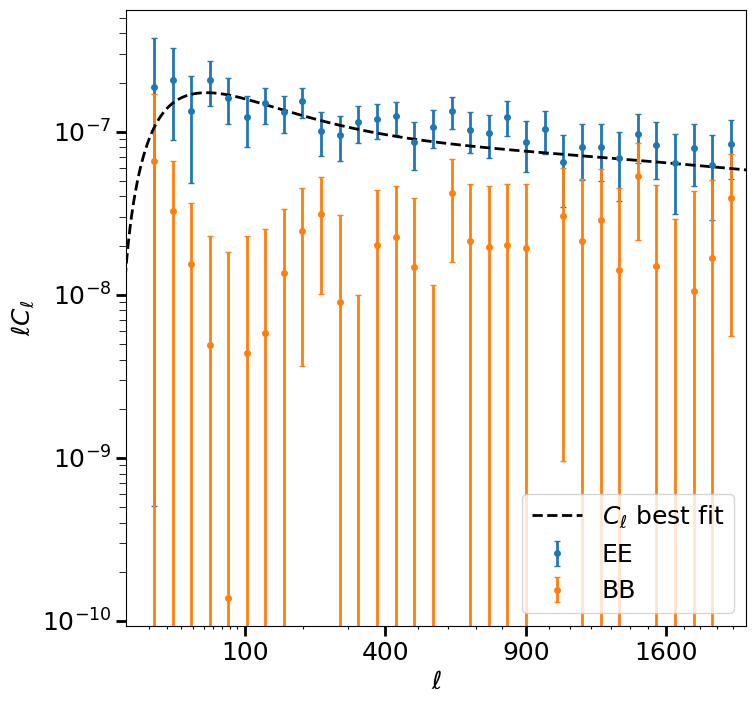

In [8]:
import healpy as hp
import utils
import matplotlib.scale as mscale

mscale.register_scale(utils.SquareRootScale)

nside = 1024
lmax = 2*nside
l = np.arange(lmax+1)
pw = hp.pixwin(nside, lmax=lmax)

pseudo_cl_glass = cv._pseudo_cls['SP_v1.4.5.A']['pseudo_cl']
cov_cl_glass = cv._pseudo_cls['SP_v1.4.5.A']['cov']

ell_eff = pseudo_cl_glass['ELL']

fig, ax = plt.subplots(figsize=(8, 8))

ax.errorbar(ell_eff, ell_eff*pseudo_cl_glass['EE'], yerr=ell_eff*np.sqrt(np.diag(cov_cl_glass["COVAR_EE_EE"].data)), fmt='o', capsize=2, markersize=4, label='EE')
ax.errorbar(ell_eff, ell_eff*pseudo_cl_glass['BB'], yerr=ell_eff*np.sqrt(np.diag(cov_cl_glass["COVAR_BB_BB"].data)), fmt='o', capsize=2, markersize=4, label='BB')
#ax.plot(l, l*theory_cls['W1xW1'], label=r'$C_\ell$ theory', c='k', ls='--')
ax.plot(ell, ell*cl_best_fit, label=r'$C_\ell$ best fit', c='k', ls='--')

ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\ell C_\ell$')

ax.set_xlim(ell_eff.min()-10, ell_eff.max()+100)
ax.set_xscale('squareroot')
ax.set_xticks(np.array([100, 400, 900, 1600]))
ax.minorticks_on()
ax.tick_params(axis='x', which='minor', length=2, width=0.8)
minor_ticks = [i*10 for i in range(1, 10)] + [i*100 for i in range(1, 21)]
ax.xaxis.set_ticks(minor_ticks, minor=True)

ax.set_yscale('log')

plt.legend()
plt.show()

## SP_v1.4.6.3

In [10]:
#PTE EB SP_v1.4.6.3
data_vector = cv._pseudo_cls["SP_v1.4.6.3_A"]["pseudo_cl"]["BB"][:]
cov = cv._pseudo_cls["SP_v1.4.6.3_A"]["cov"]["COVAR_BB_BB"].data[:, :]

In [11]:
cv._pseudo_cls["SP_v1.4.6.3_A"]

{'pseudo_cl': FITS_rec([(  12.5, 1.11069048e-08, -2.74693754e-09,  5.82452465e-09),
           (  24. , 1.01268801e-08, -1.66903133e-09,  1.47344135e-09),
           (  38.5, 3.17962324e-09,  2.33207535e-10,  1.24828169e-10),
           (  56.5, 3.13415473e-09,  1.92004851e-10,  5.38332683e-11),
           (  78. , 2.22338661e-09,  5.31152932e-11, -1.16410923e-10),
           ( 103. , 1.25455313e-09,  1.90215067e-11,  5.82221056e-11),
           ( 131.5, 1.11368655e-09,  2.98053318e-11,  2.44969483e-10),
           ( 163.5, 7.85570584e-10,  2.32142728e-11,  5.89500535e-11),
           ( 199. , 8.10370559e-10,  6.80648531e-11,  5.06563123e-11),
           ( 238. , 4.83473878e-10,  8.40949832e-13,  1.26803211e-10),
           ( 281. , 3.94418582e-10,  1.72740612e-11,  3.18567656e-11),
           ( 327.5, 3.40274046e-10,  1.41773506e-12,  3.32703107e-11),
           ( 377. , 3.71505247e-10,  2.37908736e-11,  3.51095241e-11),
           ( 430. , 3.12461611e-10, -2.36443040e-11,  5.56719412

In [26]:
get_chi2_and_pte(data_vector, cov)

Chi2: 18.8932
Reduced Chi2: 1.1114
PTE: 0.3347


(18.89317456645998, 1.1113632097917634, 0.33469821169345293)

In [25]:
#PTE BB SP_v1.4.6.3
from astropy.io import fits
cosmo_val_outdir = "/home/guerrini/sp_validation/cosmo_val/output/"
data_vector = fits.getdata(cosmo_val_outdir+"/pseudo_cl_SP_v1.4.6.3_B_leak_corr.fits")["BB"][12:-3]
cov = fits.open(cosmo_val_outdir+"/pseudo_cl_cov_SP_v1.4.6.3_B_leak_corr.fits")["COVAR_BB_BB"].data[12:-3, 12:-3]

In [32]:
path_gaussian_sims = "/home/guerrini/sp_validation/cosmo_val/harmonic_covariance_gaussian_sims_v1463_B/"
for i in range(10_000):
    sim_cl = np.load(
        path_gaussian_sims + f"sample_{i}.npz"
    )
    if i == 0:
        sim_dv = sim_cl['cl_all'][1]
    else:
        sim_dv = np.vstack((sim_dv, sim_cl['cl_all'][1]))

cov_gaussian = np.cov(sim_dv.T)


In [33]:
data_vector_gaussian = fits.getdata(cosmo_val_outdir+"/pseudo_cl_SP_v1.4.6.3_A_leak_corr.fits")["EB"]
get_chi2_and_pte(data_vector_gaussian[12:-4], cov_gaussian[12:-4, 12:-4])

Chi2: 16.7303
Reduced Chi2: 1.0456
PTE: 0.4033


(16.730313439455436, 1.0456445899659648, 0.40325245161967527)

In [30]:
get_chi2_and_pte(data_vector, cov_gaussian)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 32 is different from 17)

In [24]:
get_chi2_and_pte(data_vector, cov)

Chi2: 18.8705
Reduced Chi2: 1.1100
PTE: 0.3360


(18.87047462756866, 1.1100279192687448, 0.3360172855953497)

## SP_v1.4.5_leak_corr

In [9]:
#PTE EB SP_v1.4.5
data_vector = cv._pseudo_cls["SP_v1.4.5_intermediate"]["pseudo_cl"]["EB"]
cov = cv._pseudo_cls["SP_v1.4.5_intermediate"]["cov"]["COVAR_EB_EB"].data

In [10]:
get_chi2_and_pte(data_vector, cov)

Chi2: 20.9722
Reduced Chi2: 0.6554
PTE: 0.9323


(20.97219165111411, 0.6553809890973159, 0.9322719339092785)

In [11]:
# PTE BB SP_v1.4.5_leak_corr
data_vector = cv._pseudo_cls["SP_v1.4.5_intermediate"]["pseudo_cl"]["BB"][:]
cov = cv._pseudo_cls["SP_v1.4.5_intermediate"]["cov"]["COVAR_BB_BB"].data[:, :]

In [12]:
get_chi2_and_pte(data_vector, cov)

Chi2: 40.3352
Reduced Chi2: 1.2605
PTE: 0.1480


(40.33515487940795, 1.2604735899814985, 0.14803821393657934)

## SP_v1.4.1

In [13]:
#PTE EB SP_v1.4.5
data_vector = cv._pseudo_cls["SP_v1.4.5_bright"]["pseudo_cl"]["EB"]
cov = cv._pseudo_cls["SP_v1.4.5_bright"]["cov"]["COVAR_EB_EB"].data

In [14]:
get_chi2_and_pte(data_vector, cov)

Chi2: 15.9803
Reduced Chi2: 0.4994
PTE: 0.9919


(15.980318554834675, 0.4993849548385836, 0.9918574295262937)

In [15]:
#PTE BB SP_v1.4.5
data_vector = cv._pseudo_cls["SP_v1.4.5_bright"]["pseudo_cl"]["BB"][:]
cov = cv._pseudo_cls["SP_v1.4.5_bright"]["cov"]["COVAR_BB_BB"].data[:, :]

In [16]:
get_chi2_and_pte(data_vector, cov)

Chi2: 29.0115
Reduced Chi2: 0.9066
PTE: 0.6186


(29.011536180654744, 0.9066105056454608, 0.6185772830154228)

In [90]:
get_chi2_and_pte(data_vector[1:-12], cov[1:-12, 1:-12])

Chi2: 26.4131
Reduced Chi2: 1.3902
PTE: 0.1191


(np.float64(26.413105945441888),
 np.float64(1.390163470812731),
 np.float64(0.11908387555743039))

In [79]:
cov_141 = cv._pseudo_cls["SP_v1.4.1"]["cov"]["COVAR_BB_BB"].data
cov_145 = cv._pseudo_cls["SP_v1.4.5"]["cov"]["COVAR_BB_BB"].data

data_vector_sim = np.load("/home/guerrini/random_stuff/cl.npy")
cov_141_sim = np.load("/home/guerrini/random_stuff/cov_cl.npy")
cov_145_sim = np.load("/home/guerrini/random_stuff/cov_cl_1.4.5.npy")

corr_141 = np.array(
    [[1/(cov_141[i,i]*cov_141[j,j]) for i in range(32)] for j in range(32)]
)
corr_141 = cov_141*np.sqrt(corr_141)

corr_145 = np.array(
    [[1/(cov_145[i,i]*cov_145[j,j]) for i in range(32)] for j in range(32)]
)
corr_145 = cov_145*np.sqrt(corr_145)

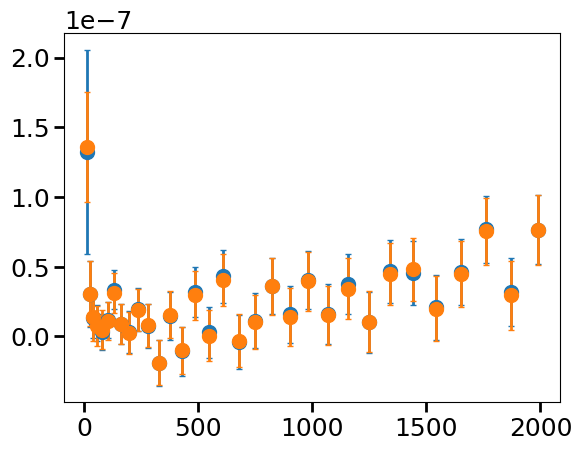

In [84]:
ell = cv._pseudo_cls["SP_v1.4.1"]["pseudo_cl"]["ELL"]

plt.figure()

plt.errorbar(ell, ell*data_vector, yerr=ell*np.sqrt(np.diag(cov_141)), fmt='o', label='SP_v1.4.1', capsize=2)
plt.errorbar(ell, ell*data_vector_sim[3], yerr=ell*np.sqrt(np.diag(cov_141_sim[3])), fmt='o', label='SP_v1.4.1_sim', capsize=2)


plt.show()

In [81]:
data_vector_sim.shape

(4, 32)

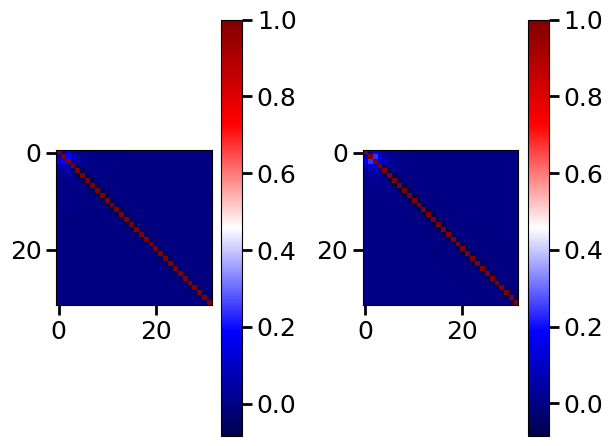

In [39]:
plt.figure()

plt.subplot(121)

plt.imshow(corr_141, cmap='seismic')
plt.colorbar()

plt.subplot(122)

plt.imshow(corr_145, cmap='seismic')
plt.colorbar()

plt.tight_layout()
plt.show()

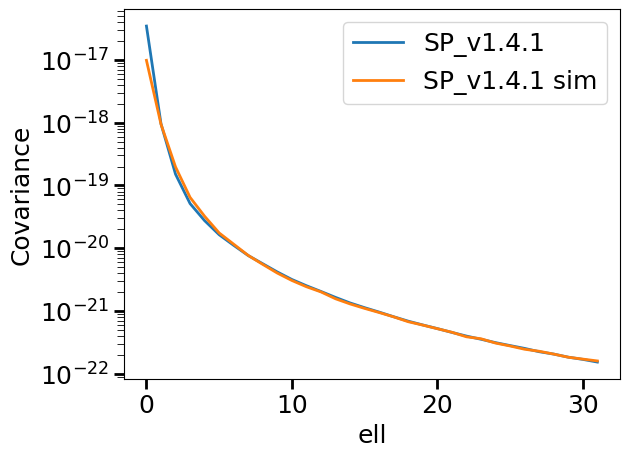

In [53]:
plt.figure()

plt.plot(np.diag(cov_141), label="SP_v1.4.1")
#plt.plot(np.diag(cov_145), label="SP_v1.4.5")
plt.plot(np.diag(cov_141_sim[3]), label="SP_v1.4.1 sim")
#plt.plot(np.diag(cov_145_sim[3]), label="SP_v1.4.5 sim")

plt.legend()
plt.xlabel("ell")
plt.ylabel("Covariance")

plt.yscale("log")

plt.show()

In [56]:
cov_141_sim[3].shape

(32, 32)

In [61]:
n_sims = 8000
n_dv = 32
hartlap_factor = (n_sims-n_dv-2)/(n_sims-1)
print(hartlap_factor)

0.9958744843105388


In [71]:
data_vector @ np.linalg.inv(cov_141_sim[3]) @ data_vector

np.float64(72.76617421925721)